In [23]:
import pandas as pd
import numpy as np

In [24]:
cddd = pd.read_csv('./cddd.csv', sep=',')

In [25]:
cddd.head()

,SMILES,cddd_1,cddd_2,cddd_3,cddd_4,cddd_5,cddd_6,cddd_7,cddd_8,cddd_9,...,cddd_503,cddd_504,cddd_505,cddd_506,cddd_507,cddd_508,cddd_509,cddd_510,cddd_511,cddd_512
0,CCCC(=O)n1cc2c3c(cccc31)C1=CC(C(=O)N(CC)CC)CN(...,-0.718049,-0.591865,-0.106980,-0.312840,0.219249,0.859029,0.215116,-0.279703,-0.013580,...,-0.061929,-0.522132,-0.411223,-0.061713,-0.999750,-0.299506,-0.443911,0.603580,0.682553,0.529631
1,CCCCC(=O)n1cc2c3c(cccc31)C1=CC(C(=O)N(CC)CC)CN...,-0.737155,-0.499192,0.007333,-0.103446,0.303232,0.832778,0.253275,-0.269078,0.102099,...,-0.056103,-0.547141,-0.317401,0.131483,-0.999787,-0.240509,-0.349134,0.618411,0.730728,0.621695
2,CCN(CC)C(=O)C1C=C2c3cccc4c3c(cn4C(=O)C3CC3)CC2...,-0.555204,-0.241225,0.229048,-0.016159,0.198835,-0.148527,0.134711,-0.223602,-0.175264,...,-0.573399,0.320871,-0.790851,-0.050697,-0.999551,-0.328965,0.289075,0.398955,0.698012,0.263331
3,CCC(=O)n1cc2c3c(cccc31)C1=CC(C(=O)N(CC)CC)CN(C...,-0.718344,-0.715166,-0.218785,-0.437241,0.011070,0.792712,0.359004,-0.336653,-0.011839,...,-0.167550,-0.595692,-0.583103,0.021646,-0.999706,-0.160209,-0.380013,0.560662,0.642401,0.463889
4,CNC(C)C(=O)c1ccccc1Cl,-0.252168,0.313930,0.256497,-0.355868,-0.586036,-0.454398,-0.187400,-0.438383,-0.266913,...,0.179232,0.134745,-0.000620,-0.206541,0.003378,-0.158811,0.265426,0.332642,0.519545,-0.064433


In [26]:
sum(cddd.cddd_1.isnull())

14

In [27]:
train = pd.read_csv('./train.csv', sep=',')

In [28]:
train.head()

,Compound,SMILES,Lab,RT,mol,ECFP_1,ECFP_2,ECFP_3,ECFP_4,ECFP_5,...,ECFP_1015,ECFP_1016,ECFP_1017,ECFP_1018,ECFP_1019,ECFP_1020,ECFP_1021,ECFP_1022,ECFP_1023,ECFP_1024
0,Hydroxytriazolam,OCc1nnc2n1-c1ccc(Cl)cc1C(c1ccccc1Cl)=NC2,CFSRE,7.02,<rdkit.Chem.rdchem.Mol object at 0x2aab375ee880>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5-MeO-DIPT,COc1ccc2[nH]cc(CCN(C(C)C)C(C)C)c2c1,Aarhus,4.45,<rdkit.Chem.rdchem.Mol object at 0x2aab37643680>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MDMA,CNC(C)Cc1ccc2c(c1)OCO2,Ghent University,3.14,<rdkit.Chem.rdchem.Mol object at 0x2aab378ea730>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Despropionyl N-Benzyl para-Fluoro Norfentanyl,Fc1ccc(NC2CCN(Cc3ccccc3)CC2)cc1,San Francisco OCME,5.95,<rdkit.Chem.rdchem.Mol object at 0x2aab3790f3e0>,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,N-Ethylpentylone,CCCC(NCC)C(=O)c1ccc2c(c1)OCO2,Ghent University,4.21,<rdkit.Chem.rdchem.Mol object at 0x2aab378eadc0>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# pca
# factor analysis
# 

/Users/melina/opt/anaconda3/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


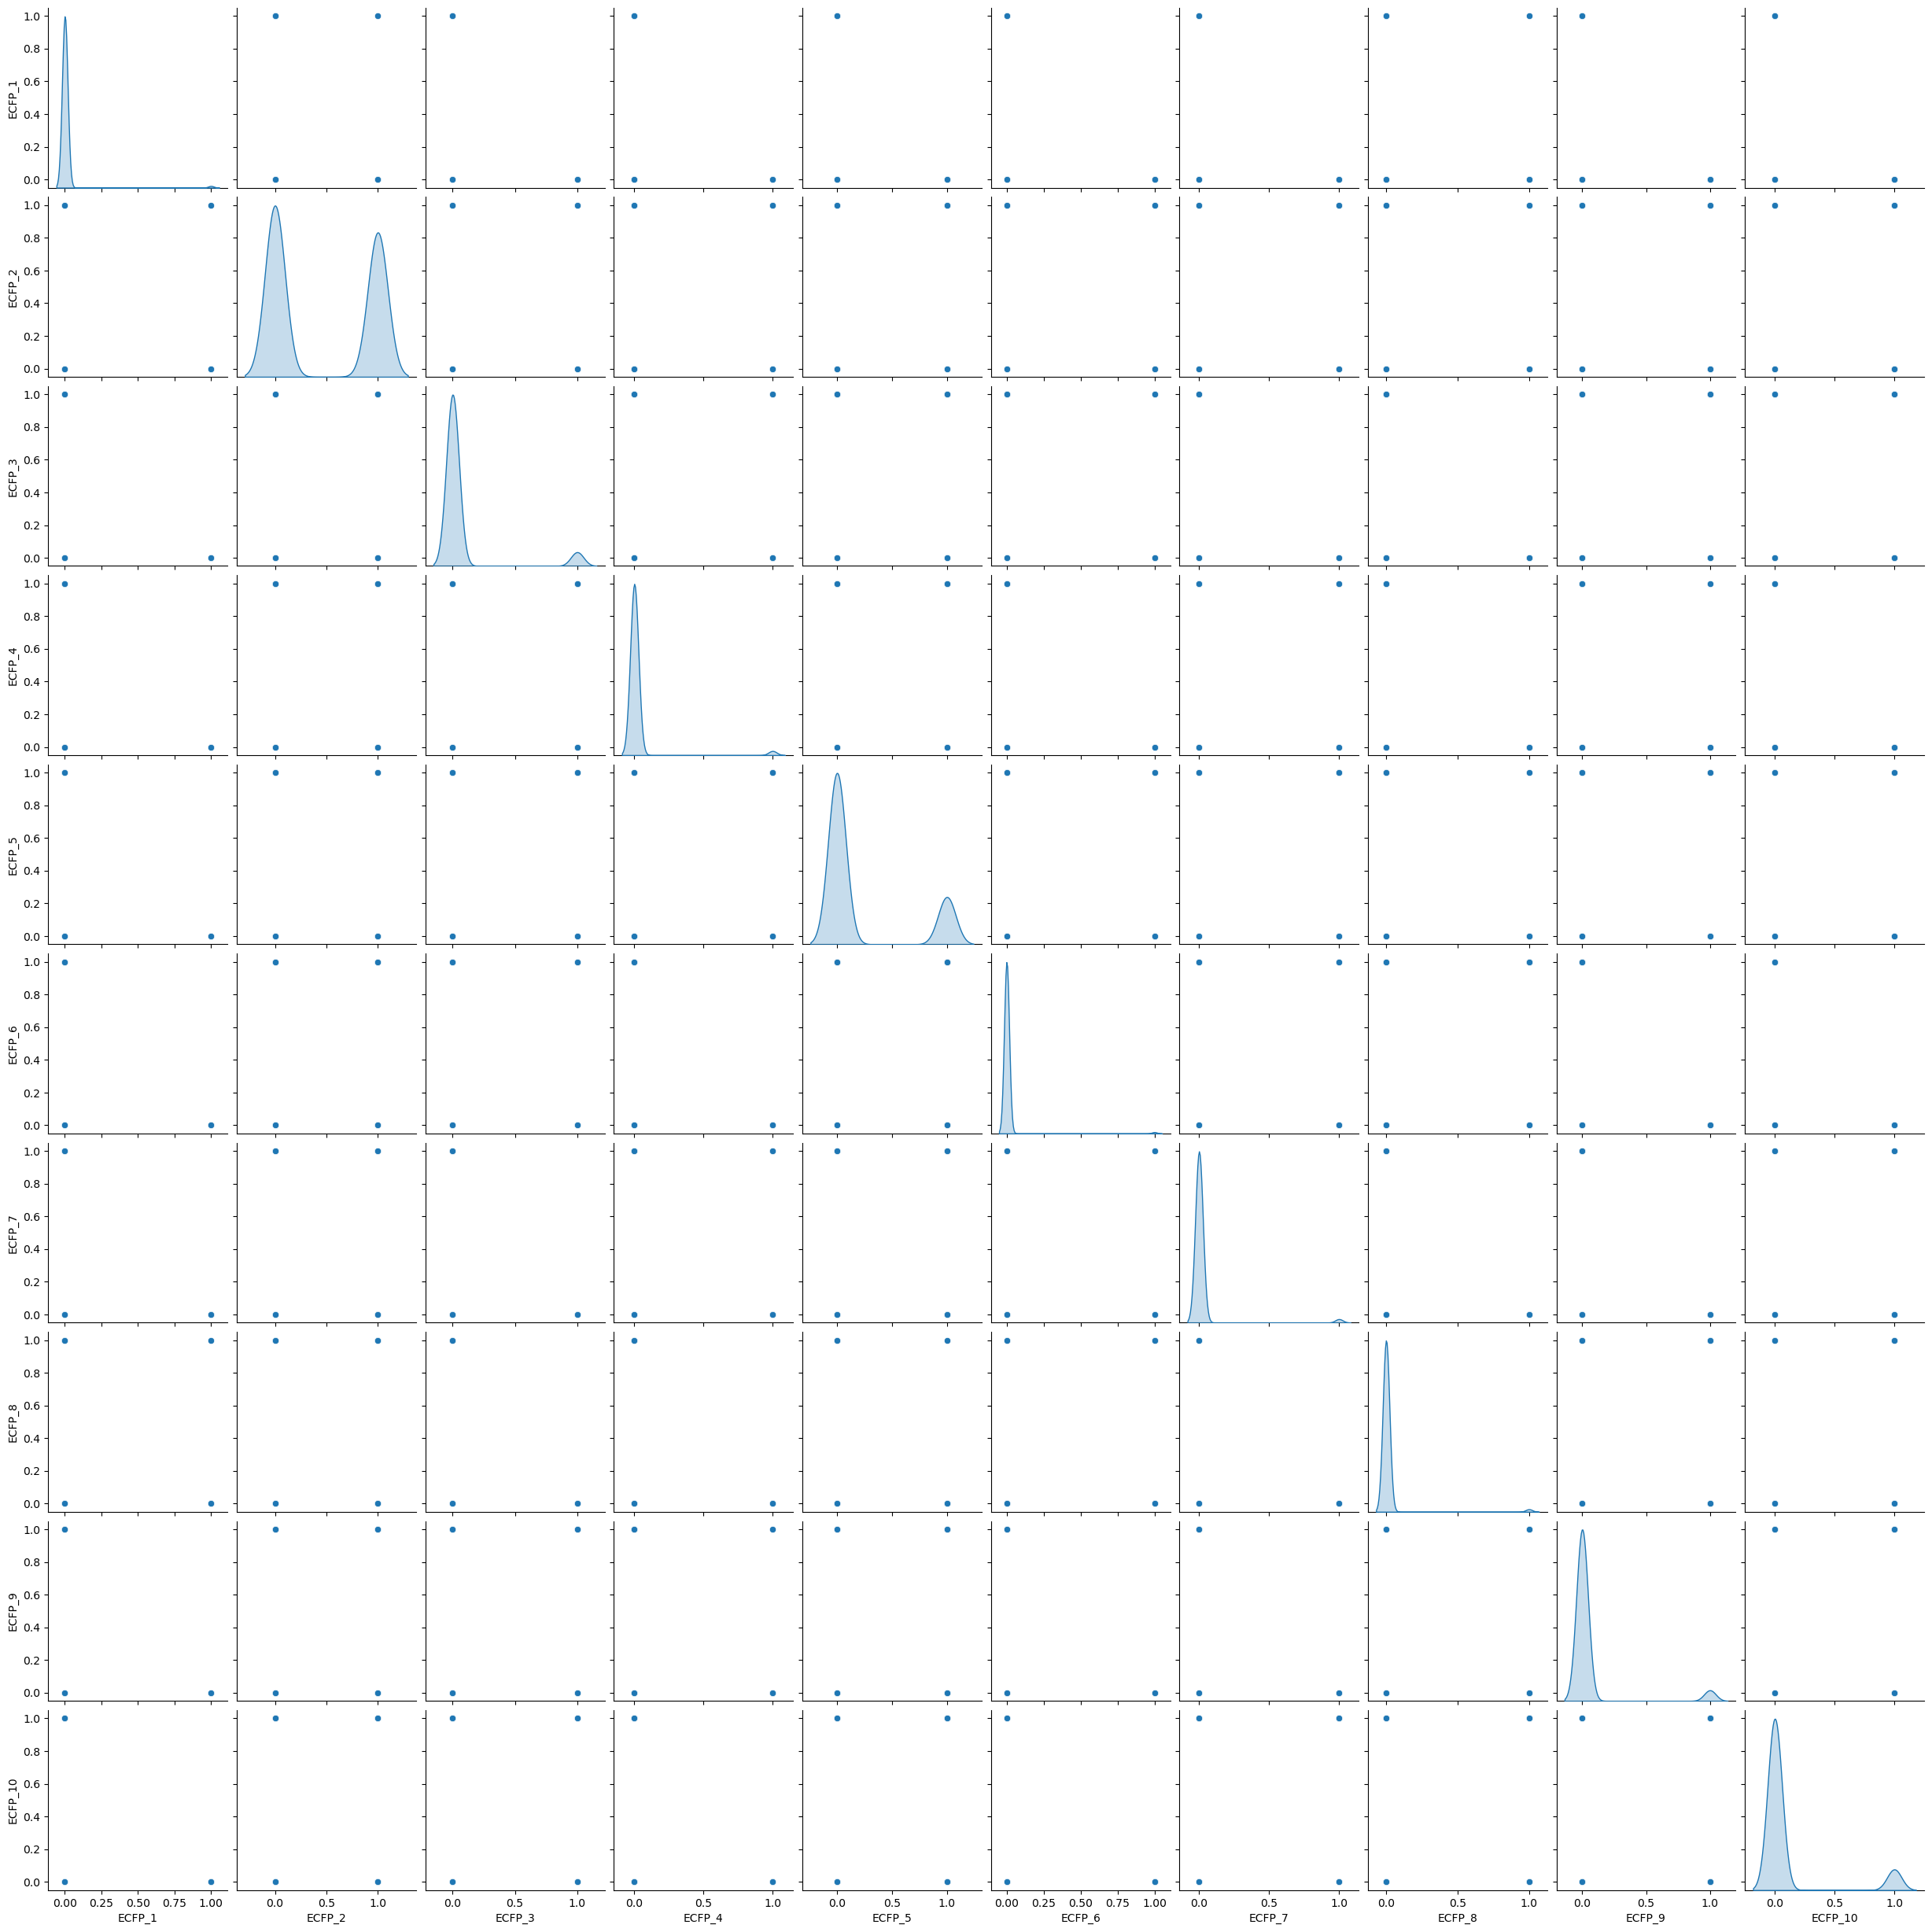

In [31]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)
sns.pairplot(df[['ECFP_1', 'ECFP_2', 'ECFP_3', 'ECFP_4', 'ECFP_5', 'ECFP_6', 'ECFP_7', 'ECFP_8', 'ECFP_9', 'ECFP_10']], diag_kind='kde')
plt.show()

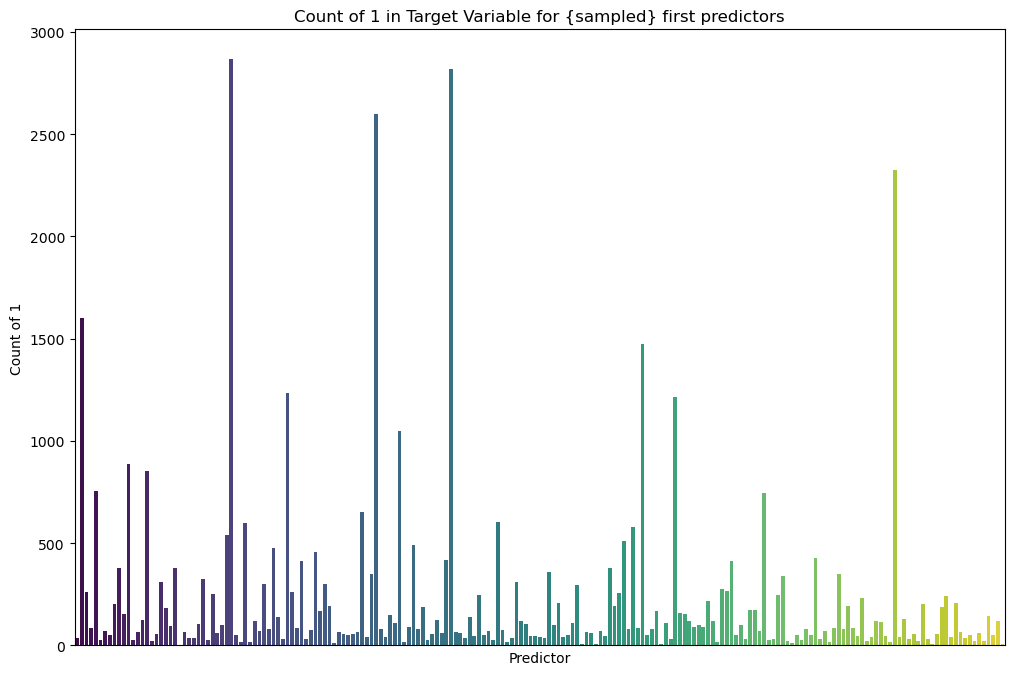

In [43]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)
sampled = 200
# Choose a subset of predictors for visualization (e.g., first 5 predictors)
subset_predictors = df.iloc[:, 1:sampled]

# Concatenate the predictors with the target variable
data_to_plot = pd.concat([subset_predictors, df['RT']], axis=1)


# Reshape the data for Seaborn bar plots
data_to_plot_melted = data_to_plot.melt(id_vars='RT', var_name='Predictor', value_name='Binary Value')

# Filter rows where Binary Value is 1
data_to_plot_melted = data_to_plot_melted[data_to_plot_melted['Binary Value'] == 1]

# Create bar plots
plt.figure(figsize=(12, 8))
sns.countplot(data=data_to_plot_melted, x='Predictor', palette='viridis')
plt.title('Count of 1 in Target Variable for {sampled} first predictors')
plt.xlabel('Predictor')
plt.ylabel('Count of 1')
plt.xticks(rotation=45, ha='right')
plt.xticks([], [])  # Hide x-axis ticks

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)
sampled = 200
# Choose a subset of predictors for visualization (e.g., first 5 predictors)
subset_predictors = df.iloc[:, 1:sampled]
plt.show()

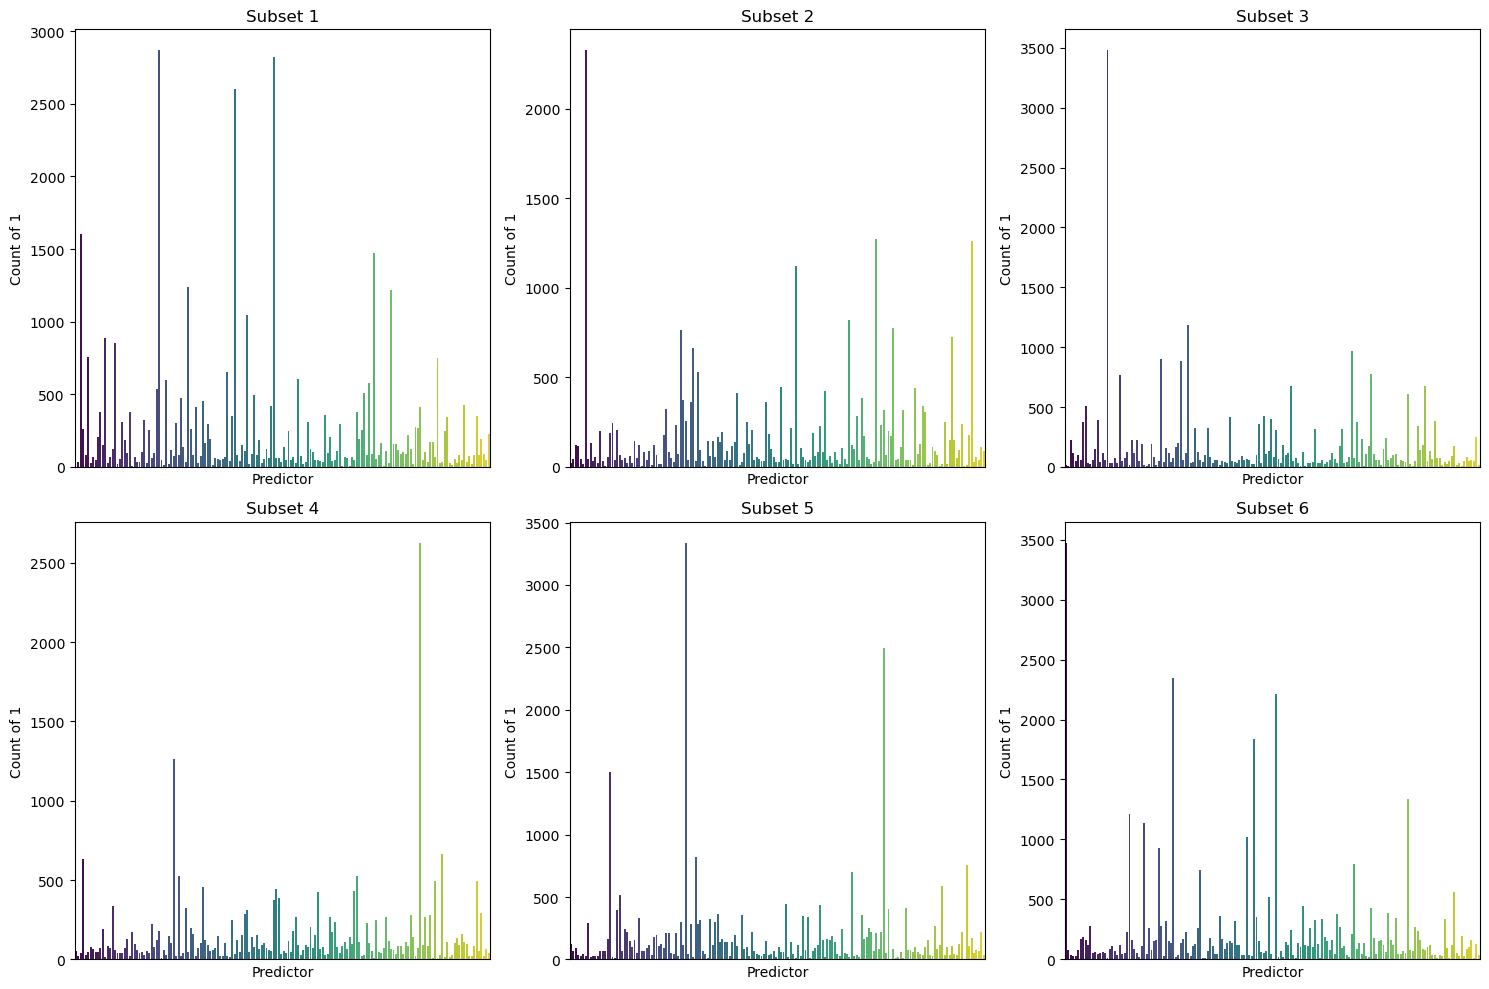

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)
# Choose a subset of predictors for visualization (e.g., first 5 predictors)

# Number of rows and columns for the subplot grid
num_rows = 2
num_cols = 3
num_subsets = num_rows * num_cols

# Calculate the number of predictors in each subset
predictors_per_subset = len(df.columns) // num_subsets

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))

# Flatten the 2D array of subplots to simplify indexing
axes = axes.flatten()

# Loop through subsets
for i, ax in enumerate(axes):
    # Calculate the starting and ending index for the subset
    start_idx = i * predictors_per_subset
    end_idx = (i + 1) * predictors_per_subset

    # Subset the predictors
    subset_predictors = df.iloc[:, start_idx:end_idx]

    # Add the target variable to the subset
    subset_predictors['target_variable'] = df['RT']

    # Reshape the data for Seaborn bar plots
    data_to_plot_melted = subset_predictors.melt(id_vars='target_variable', var_name='Predictor', value_name='Binary Value')

    # Filter rows where Binary Value is 1
    data_to_plot_melted = data_to_plot_melted[data_to_plot_melted['Binary Value'] == 1]

    # Create bar plots
    sns.countplot(data=data_to_plot_melted, x='Predictor', palette='viridis', ax=ax)
    ax.set_title(f'Subset {i + 1}')
    ax.set_xlabel('Predictor')
    ax.set_ylabel('Count of 1')
    ax.set_xticks([])  # Hide x-axis ticks

# Adjust layout
plt.tight_layout()
plt.show()


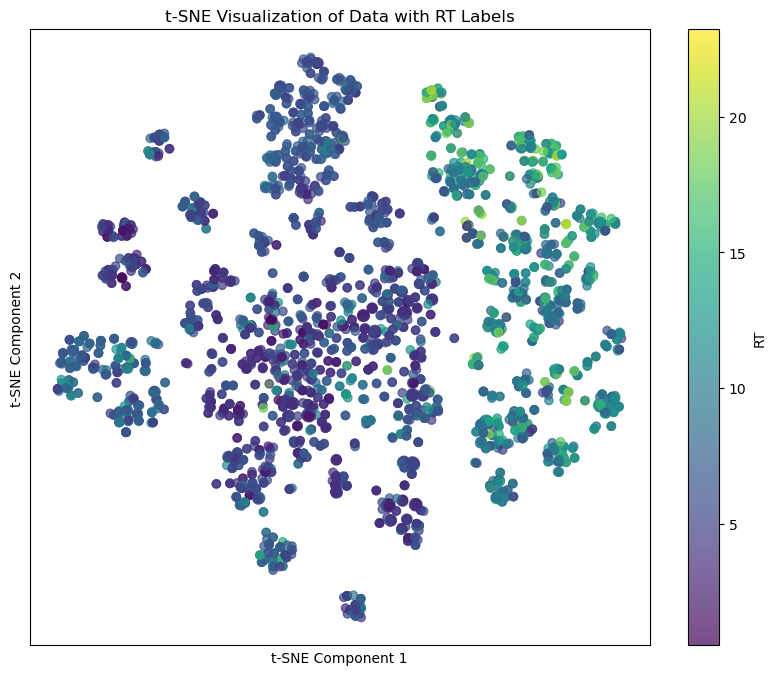

In [59]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)

# Extract the target variable
y = df['RT']

# Drop the target variable from the DataFrame
X = df.drop('RT', axis=1)

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a new DataFrame for the t-SNE results
tsne_df = pd.DataFrame(data=X_tsne, columns=['tsne1', 'tsne2'])
tsne_df['RT'] = y  # Add the target variable back to the DataFrame

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_df['tsne1'], tsne_df['tsne2'], c=tsne_df['RT'], cmap='viridis', alpha=0.7)
plt.title('t-SNE Visualization of Data with RT Labels')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='RT')
plt.xticks([], [])  # Hide x-axis ticks
plt.yticks([], [])  # Hide y-axis ticks

plt.show()

# -SNE Component 1 and Component 2: 
# These are the two new features (dimensions) created by t-SNE. 
# Each data point in your original dataset is now represented by a pair of values in this 2D space (Component 1, Component 2). 
# Similar samples in the original high-dimensional space are also close to each other in the t-SNE space.

# The interpretation of the components can be challenging because t-SNE doesn't preserve global structures. 
# Instead, it focuses on preserving local neighborhoods. Distances between points in the t-SNE plot don't have a meaningful interpretation 
# in terms of the original feature values. 

#The main use of t-SNE is in visualization and exploration of high-dimensional datasets. 
# It helps you identify clusters, patterns, or outliers in your data by looking at the 2D representation. 
# Keep in mind that t-SNE is sensitive to hyperparameters, and different runs might yield slightly different results. 
# It's often used as an exploratory tool to gain insights into the structure of your data rather than as a definitive analysis tool.

